In [18]:
import pyvcell.vcml as vc

# Antimony model

In [19]:
antimony_str = """
    // This is a simple example of a spatial model in VCell
    compartment ec = 10000;
    compartment cell = 5000;
    compartment pm = 100;
    compartment nuc = 300;
    compartment nuc_env = 40;
    species A in cell;
    species B in cell;
    J0: A -> B; k1*A - k2*B
    J0 in cell;

    k1 = 0.1; k2 = 0.2
    A = 10
"""

import antimony as sb
sbml_str = sb.getSBMLString()

# load into VCell as a Biomodel

In [20]:
biomodel = vc.load_antimony_str(antimony_str)

Found shared library: /Users/jimschaff/Documents/workspace/pyvcell/.venv_jupyter/lib/python3.11/site-packages/libvcell/lib/libvcell.dylib
2025-04-14T19:02:54.722593Z main WARN The use of package scanning to locate Log4j plugins is deprecated.
Please remove the `packages` attribute from your configuration file.
See https://logging.apache.org/log4j/2.x/faq.html#package-scanning for details.
2025-04-14 15:02:54,727 ERROR (SBMLDocument.java:573) - There was an error accessing the sbml online validator!
2025-04-14T19:02:54.733143Z main WARN The Logger cbit.vcell.model.Kinetics was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@1a73fd0c and is now requested with a null message factory (defaults to org.apache.logging.log4j.message.ParameterizedMessageFactory), which may create log events with unexpected formatting.
2025-04-14 15:02:54,735  WARN (SBMLImporter.java:2878) - failed to transform lumped reaction J0 to distributed: linear factor was null, lu

# correct model

In [21]:
model = biomodel.model
model.get_compartment("pm").dim = 2
model.get_compartment("nuc_env").dim = 2
display(model)
display(model.parameter_values)

Model(compartments=['ec', 'cell', 'pm', 'nuc', 'nuc_env'], species=['A', 'B'], reactions=['J0'], parameters=['k1', 'k2'])

{'k1': 0.1, 'k2': 0.2, 'J0.LumpedJ': '((k1 * A) - (k2 * B))'}

# load another VCML file and copy the geometry

In [22]:
tutorial_biomodel = vc.load_vcml_url("https://raw.githubusercontent.com/virtualcell/pyvcell/refs/heads/main/examples/models/Tutorial_MultiApp_PDE.vcml")
display(tutorial_biomodel)

Biomodel(model=Model(compartments=['cyt', 'nuc', 'EC', 'pm', 'nm'], species=['Ran_cyt', 'C_cyt', 'RanC_nuc', 'RanC_cyt'], reactions=['r0', 'flux0'], parameters=[]), applications=['3D pde'], simulations=['Simulation4'])

In [23]:
tutorial_geometry = tutorial_biomodel.applications[0].geometry
print("subvolume names: ", tutorial_geometry.subvolume_names)
print("surface-class names: ", tutorial_geometry.surface_class_names)

subvolume names:  ['ec', 'cytosol', 'Nucleus']
surface-class names:  ['cytosol_ec_membrane', 'Nucleus_cytosol_membrane']


# add an application to the biomodel

In [24]:
app = biomodel.add_application("app1", geometry=tutorial_geometry)
app.map_compartment("cell", "cytosol")
app.map_compartment("ec", "ec")
app.map_compartment("nuc", "Nucleus")
app.map_compartment("nuc_env", "Nucleus_cytosol_membrane")
app.map_compartment("pm", "cytosol_ec_membrane")
app.map_species("A", init_conc="sin(0.2*x)", diff_coef=1.0)
app.map_species("B", init_conc="cos(0.2*(x+y+z))", diff_coef=1.0)

sim = app.add_sim(name="sim1", duration=2.0, output_time_step=0.5, mesh_size=(50, 50, 50))

In [25]:
results = vc.simulate(biomodel=biomodel, simulation="sim1")

Found shared library: /Users/jimschaff/Documents/workspace/pyvcell/.venv_jupyter/lib/python3.11/site-packages/libvcell/lib/libvcell.dylib
2025-04-14T19:03:00.699075Z main WARN The use of package scanning to locate Log4j plugins is deprecated.
Please remove the `packages` attribute from your configuration file.
See https://logging.apache.org/log4j/2.x/faq.html#package-scanning for details.
2025-04-14T19:03:00.705435Z main WARN The Logger cbit.vcell.model.Kinetics was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@f7da579 and is now requested with a null message factory (defaults to org.apache.logging.log4j.message.ParameterizedMessageFactory), which may create log events with unexpected formatting.
2025-04-14T19:03:01.018381Z main WARN The Logger cbit.vcell.mapping.AbstractMathMapping was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@f7da579 and is now requested with a null message factory (defaults to 

Simulation Complete in Main() ... 


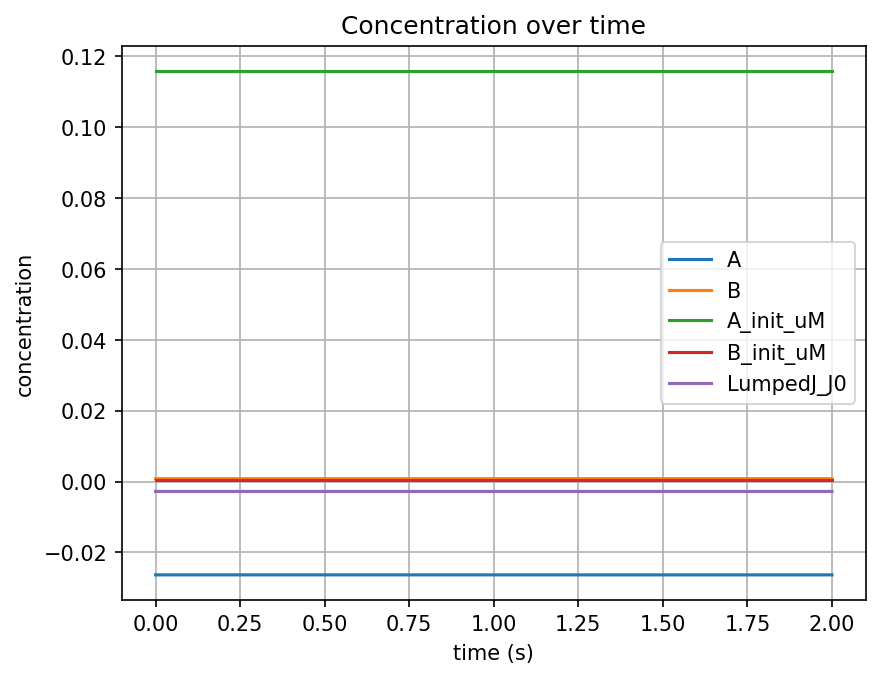

In [26]:
results.plotter.plot_concentrations()

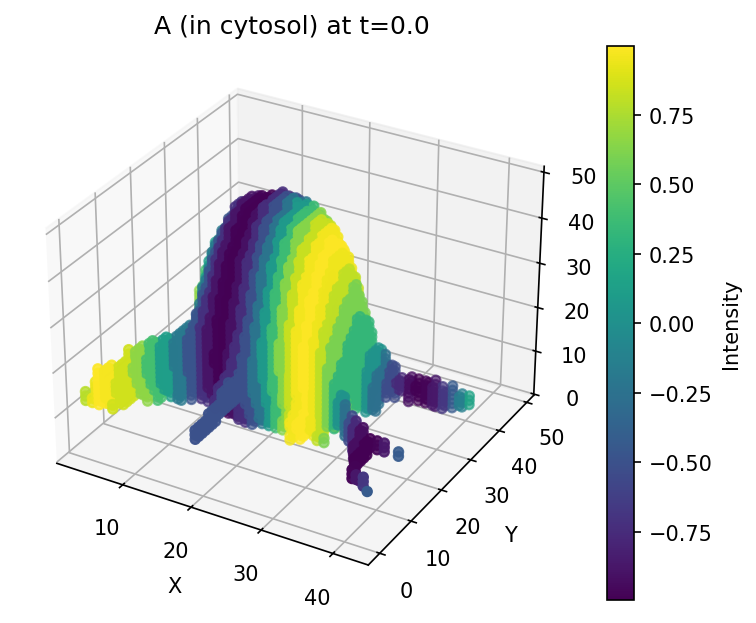

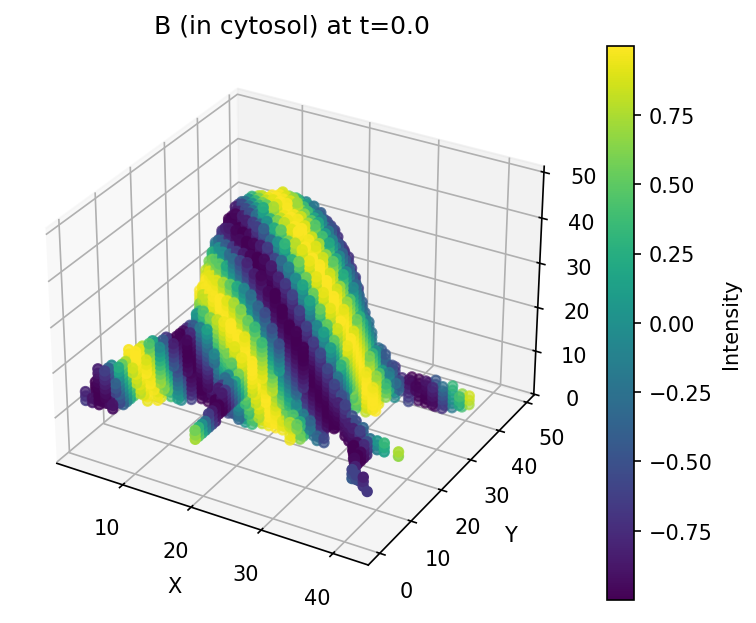

In [27]:
results.plotter.plot_slice_3d(time_index=0,channel_id="A")
results.plotter.plot_slice_3d(time_index=0,channel_id="B")